# FailBench Dataset Inspection (whole-version aggregate)

Aggregate stats across an entire dataset version — every scene, every task. Use this to verify a full generation run before committing to ML training.

Companion to `visualize_dataset.ipynb` (which drills into a single task slice). Point `DATASET_ROOT` at `datasets/<version>/`.

In [1]:
import os, sys, glob, csv
from collections import Counter, defaultdict

import numpy as np
import matplotlib.pyplot as plt

REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
os.chdir(REPO_ROOT)
sys.path.insert(0, REPO_ROOT)

DATASET_ROOT = "datasets/v10"   # edit this to inspect another version

scenes = sorted(
    d for d in os.listdir(DATASET_ROOT)
    if os.path.isdir(os.path.join(DATASET_ROOT, d))
)
print(f"DATASET_ROOT = {DATASET_ROOT}")
print(f"scenes ({len(scenes)}): {scenes}")

# Per-scene table-top z (m). Drops contact points below this — they are arm
# hits on table legs / floor, not informative for the workspace-damage signal.
SCENE_TABLE_Z = {
    "scene_level2":    0.40,
    "scene_kitchen":   0.760,
    "scene_workshop":  0.824,
    "scene_grocery":   0.760,
    "scene_cluttered": 0.760,
}

def above_table_mask(positions, scene_name, margin=0.0):
    """Boolean mask: True where contact world-z >= table_z + margin."""
    return positions[:, 2] >= (SCENE_TABLE_Z[scene_name] + margin)

CONTACT_Z_MARGIN = 0.0   # raise (e.g. 0.02) to also drop edge-of-table grazes


DATASET_ROOT = datasets/v10
scenes (5): ['scene_cluttered', 'scene_grocery', 'scene_kitchen', 'scene_level2', 'scene_workshop']


## 1. Counts and disk usage

Per-(scene, task) sample counts and total bytes on disk. The first table tells you which tasks ran short of the planned trial budget — typically due to MuJoCo crashes during failure cascades.

In [2]:
rows = []
for scene in scenes:
    sdir = os.path.join(DATASET_ROOT, scene)
    tasks = sorted(t for t in os.listdir(sdir) if os.path.isdir(os.path.join(sdir, t)))
    for task in tasks:
        tdir = os.path.join(sdir, task)
        files = glob.glob(os.path.join(tdir, "*.npz"))
        nbytes = sum(os.path.getsize(f) for f in files)
        rows.append((scene, task, len(files), nbytes))

scene_totals = defaultdict(lambda: [0, 0])
for s, t, n, b in rows:
    scene_totals[s][0] += n
    scene_totals[s][1] += b
grand_n = sum(v[0] for v in scene_totals.values())
grand_b = sum(v[1] for v in scene_totals.values())

print(f"{'scene':18s} {'task':22s} {'npz':>6s} {'MB':>9s}")
print("-" * 58)
for s, t, n, b in rows:
    print(f"{s:18s} {t:22s} {n:6d} {b/1024/1024:9.1f}")
print("-" * 58)
for s, (n, b) in scene_totals.items():
    print(f"{s:18s} {'(total)':22s} {n:6d} {b/1024/1024:9.1f}")
print("-" * 58)
print(f"{'GRAND TOTAL':40s} {grand_n:6d} {grand_b/1024/1024:9.1f}  ({grand_b/1024/1024/1024:.2f} GB)")

scene              task                      npz        MB
----------------------------------------------------------
scene_cluttered    clean_far                 276     744.7
scene_cluttered    clean_nominal             451    1239.9
scene_cluttered    clean_over                351     938.3
scene_cluttered    handover_far              201     548.4
scene_cluttered    handover_nominal          450    1215.9
scene_cluttered    handover_over             426    1168.5
scene_cluttered    stack_far                 451    1253.8
scene_cluttered    stack_nominal             450    1249.9
scene_cluttered    stack_over                376    1023.4
scene_grocery      clean_far                  51     138.3
scene_grocery      clean_nominal             501    1346.1
scene_grocery      clean_over                326     874.6
scene_grocery      handover_far              476    1291.9
scene_grocery      handover_nominal          451    1228.8
scene_grocery      handover_over             301     801

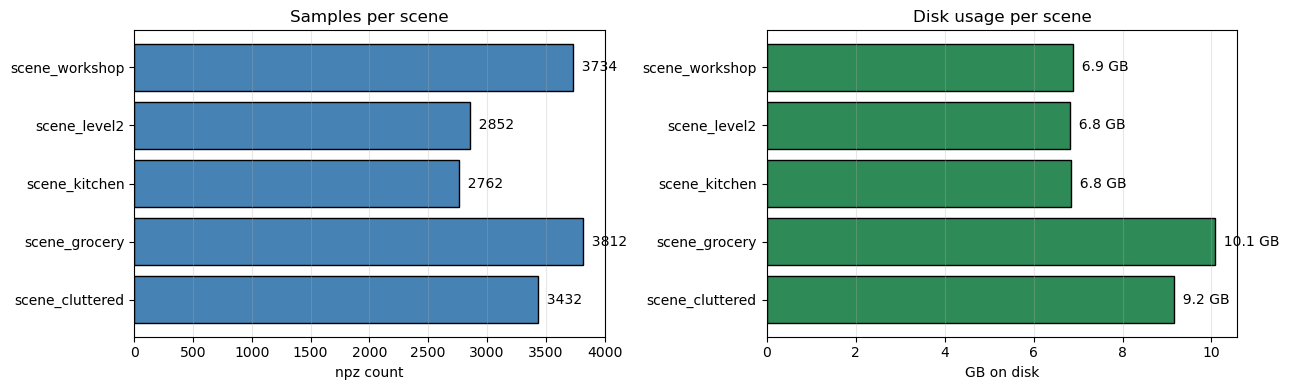

In [3]:
# Per-scene bar chart
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
names = list(scene_totals.keys())
ns = [scene_totals[s][0] for s in names]
bs = [scene_totals[s][1] / 1024**3 for s in names]
axes[0].barh(names, ns, color='steelblue', edgecolor='k')
axes[0].set(xlabel='npz count', title='Samples per scene')
axes[0].grid(axis='x', alpha=0.3)
for i, n in enumerate(ns):
    axes[0].text(n, i, f'  {n}', va='center')

axes[1].barh(names, bs, color='seagreen', edgecolor='k')
axes[1].set(xlabel='GB on disk', title='Disk usage per scene')
axes[1].grid(axis='x', alpha=0.3)
for i, b in enumerate(bs):
    axes[1].text(b, i, f'  {b:.1f} GB', va='center')
plt.tight_layout(); plt.show()

## 2. Manifest aggregation (cheap — reads CSVs, not npz)

Pulls scalar metadata from each task's `manifest.csv` so we don't have to open all 16,500+ npz files. Gives us trajectory_progress, contact counts, collision flags, qvel norm — enough for the diagnostics below.

In [4]:
manifests = []
for scene in scenes:
    for csv_path in sorted(glob.glob(os.path.join(DATASET_ROOT, scene, "*", "manifest.csv"))):
        task = os.path.basename(os.path.dirname(csv_path))
        with open(csv_path) as f:
            for r in csv.DictReader(f):
                r['scene'] = scene
                r['_task'] = task
                manifests.append(r)
print(f"loaded {len(manifests)} manifest rows")

# Convert numeric fields
for r in manifests:
    r['traj_progress'] = float(r['traj_progress'])
    r['num_contacts'] = int(r['num_contacts'])
    r['num_failure_modes'] = int(r['num_failure_modes'])
    r['pre_qvel_norm'] = float(r['pre_qvel_norm'])
    r['traj_id'] = int(r['traj_id'])
    r['had_any_collision'] = (r['had_any_collision'].lower() == 'true')
    r['n_impacted_geoms'] = (
        len(r['impacted_geom_ids'].split(';')) if r['impacted_geom_ids'] else 0
    )
print(f"sample row keys: {list(manifests[0].keys())}")

loaded 16532 manifest rows
sample row keys: ['experiment_id', 'task_id', 'traj_id', 'trajectory_file', 'seed', 'traj_progress', 'num_contacts', 'num_failure_modes', 'had_any_collision', 'impacted_geom_ids', 'pre_qvel_norm', 'npz_file', 'scene', '_task', 'n_impacted_geoms']


## 3. traj_progress coverage per scene

Stratification check. Each trajectory had K=5 draws per segment × 5 segments = 25 trials. The histogram should show roughly even mass across [0, 1] (segments are not strictly equal width in fraction-space, so expect minor bumpiness).

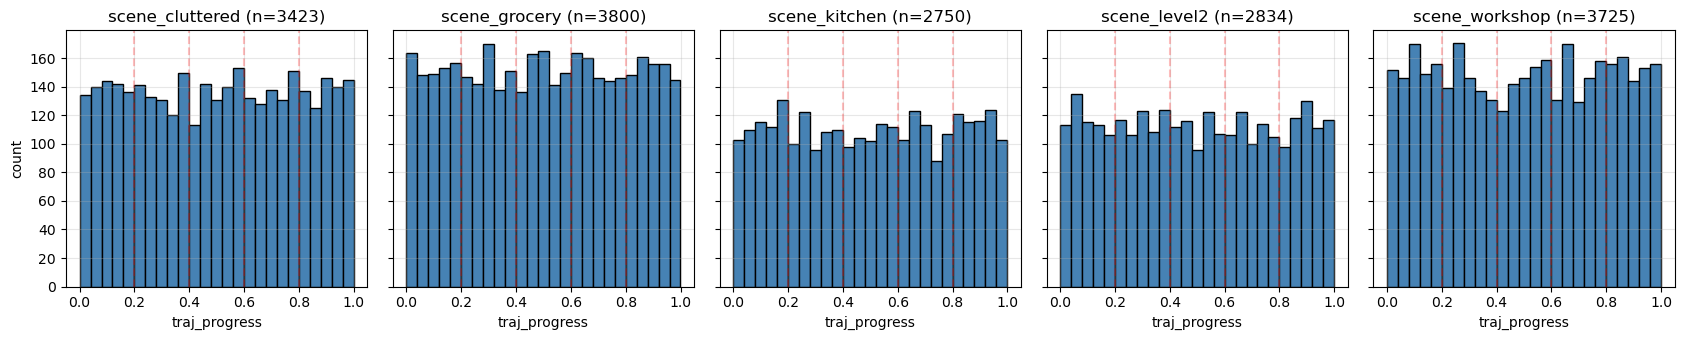

In [5]:
fig, axes = plt.subplots(1, len(scenes), figsize=(3.4 * len(scenes), 3.5), sharey=True)
if len(scenes) == 1: axes = [axes]
for ax, scene in zip(axes, scenes):
    progs = [r['traj_progress'] for r in manifests if r['scene'] == scene]
    ax.hist(progs, bins=25, color='steelblue', edgecolor='k')
    ax.set(title=f'{scene} (n={len(progs)})', xlabel='traj_progress')
    for x in [0.2, 0.4, 0.6, 0.8]:
        ax.axvline(x, color='r', ls='--', alpha=0.25)
    ax.grid(alpha=0.3)
axes[0].set_ylabel('count')
plt.tight_layout(); plt.show()

## 4. Pre-failure arm speed (`pre_qvel_norm`)

How fast the arm was moving when the failure was injected. Higher speed → more energetic post-failure cascade. Bimodality is expected: the arm decelerates near segment endpoints (descend → grasp settle, place → release) and accelerates mid-segment.

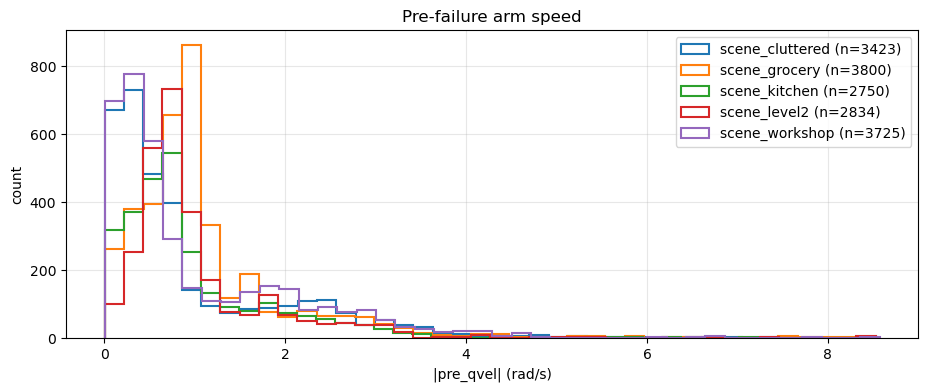

all-scenes: median=0.731, mean=1.071, max=8.573


In [6]:
fig, ax = plt.subplots(figsize=(11, 4))
for scene in scenes:
    qv = [r['pre_qvel_norm'] for r in manifests if r['scene'] == scene]
    ax.hist(qv, bins=40, histtype='step', label=f'{scene} (n={len(qv)})', linewidth=1.5)
ax.set(xlabel='|pre_qvel| (rad/s)', ylabel='count', title='Pre-failure arm speed')
ax.grid(alpha=0.3); ax.legend(); plt.show()

all_qv = [r['pre_qvel_norm'] for r in manifests]
print(f'all-scenes: median={np.median(all_qv):.3f}, mean={np.mean(all_qv):.3f}, max={np.max(all_qv):.3f}')

## 5. Contacts per sample (label density)

Each npz aggregates contacts across all 6 failure-mode forks. Higher contact counts = harder failures (ALL_JOINTS, MULTI_JOINT) or more cluttered scenes. Tail samples with very low contact counts are early-mission failures (failure happened before the arm entered the workspace).

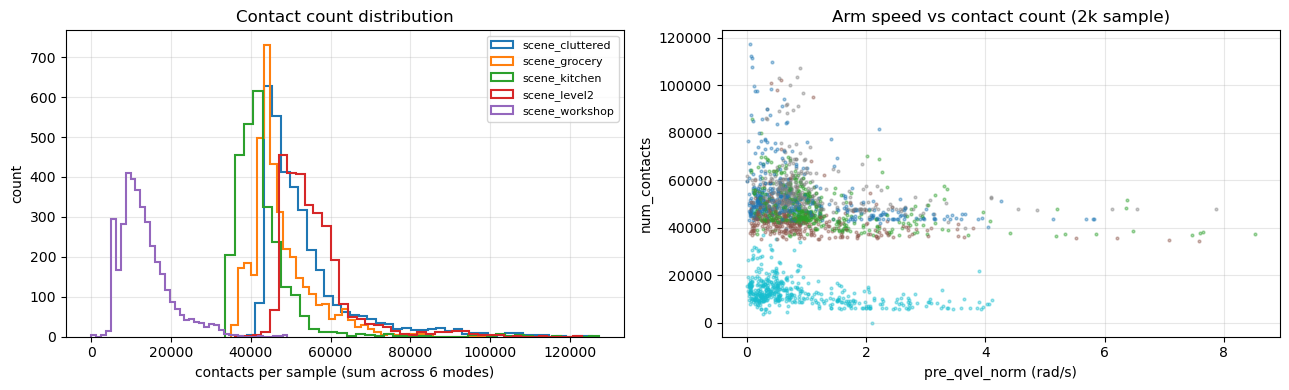

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for scene in scenes:
    nc = [r['num_contacts'] for r in manifests if r['scene'] == scene]
    axes[0].hist(nc, bins=40, histtype='step', linewidth=1.5, label=scene)
axes[0].set(xlabel='contacts per sample (sum across 6 modes)',
            ylabel='count', title='Contact count distribution')
axes[0].grid(alpha=0.3); axes[0].legend(fontsize=8)

# Pre-qvel vs num_contacts scatter (sample 2k for speed)
rng = np.random.default_rng(0)
if len(manifests) > 2000:
    sub = [manifests[i] for i in rng.choice(len(manifests), 2000, replace=False)]
else:
    sub = manifests
scene2color = {s: c for s, c in zip(scenes, plt.cm.tab10(np.linspace(0, 1, len(scenes))))}
for r in sub:
    axes[1].scatter(r['pre_qvel_norm'], r['num_contacts'],
                    c=[scene2color[r['scene']]], s=4, alpha=0.4)
axes[1].set(xlabel='pre_qvel_norm (rad/s)', ylabel='num_contacts',
            title='Arm speed vs contact count (2k sample)')
axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 6. Collision rate and impacted-geom diversity

`had_any_collision` is True for nearly every sample (the arm always touches *something* during the 500-step settle), so it's not a useful learning target. The interesting per-sample signal is the `impacted_geom_ids` set — how many distinct geoms got hit, and the diversity of impact pairs across the dataset.

had_any_collision rate: 1.0000


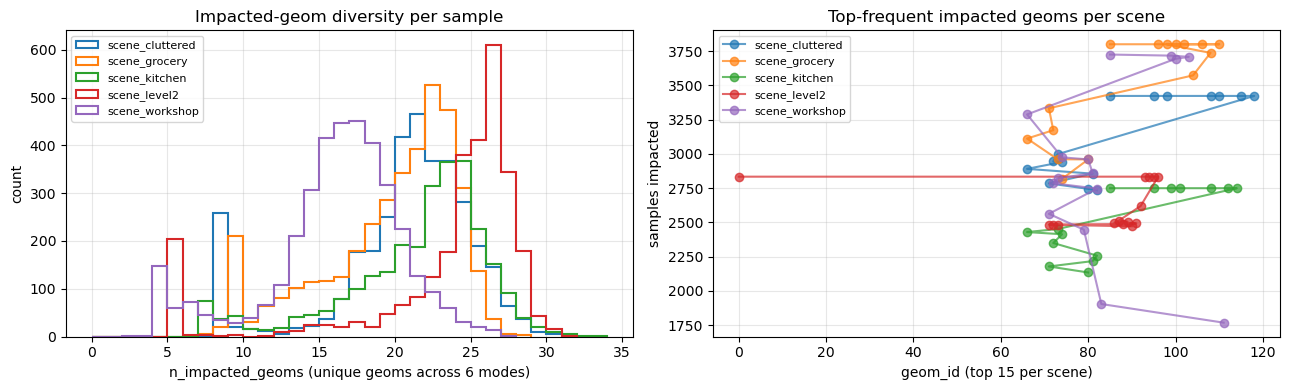

In [8]:
any_coll = sum(1 for r in manifests if r['had_any_collision']) / len(manifests)
print(f"had_any_collision rate: {any_coll:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for scene in scenes:
    counts = [r['n_impacted_geoms'] for r in manifests if r['scene'] == scene]
    axes[0].hist(counts, bins=range(0, max(counts) + 2),
                 histtype='step', linewidth=1.5, label=scene)
axes[0].set(xlabel='n_impacted_geoms (unique geoms across 6 modes)',
            ylabel='count', title='Impacted-geom diversity per sample')
axes[0].grid(alpha=0.3); axes[0].legend(fontsize=8)

# Per-scene impacted-geom-ID frequency: what gets hit, scene-by-scene
for scene in scenes:
    cnt = Counter()
    for r in manifests:
        if r['scene'] != scene: continue
        for g in r['impacted_geom_ids'].split(';'):
            if g: cnt[int(g)] += 1
    top = cnt.most_common(15)
    if not top: continue
    axes[1].plot([g for g, _ in top], [c for _, c in top],
                 marker='o', label=scene, alpha=0.7)
axes[1].set(xlabel='geom_id (top 15 per scene)', ylabel='samples impacted',
            title='Top-frequent impacted geoms per scene')
axes[1].grid(alpha=0.3); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 7. Pre-failure config diversity (a sample of pre_qpos)

The whole dataset's value depends on having diverse pre-failure arm configurations. Loads `pre_qpos` from a random subset of npz (~1k samples) and shows per-joint coverage. If any joint is collapsed (e.g. all values within 0.01 rad), the dataset is biased and the planner won't learn meaningfully across that joint.

In [9]:
import zipfile
all_files = []
for scene in scenes:
    all_files.extend(glob.glob(os.path.join(DATASET_ROOT, scene, "*", "*.npz")))
rng = np.random.default_rng(42)
sample_n = min(1000, len(all_files))
sample_files = [all_files[i] for i in rng.choice(len(all_files), sample_n, replace=False)]
print(f"loading pre_qpos from {sample_n} npz...")
qposes_list, corrupted = [], []
for f in sample_files:
    try:
        qposes_list.append(np.load(f, allow_pickle=True)["pre_qpos"])
    except (zipfile.BadZipFile, OSError, KeyError, EOFError) as e:
        corrupted.append((f, type(e).__name__))
qposes = np.array(qposes_list)
print(f"loaded {len(qposes)} ok, {len(corrupted)} corrupted ({100*len(corrupted)/sample_n:.2f}%)")
if corrupted:
    print("examples (likely worker crashes mid-write — small file size = truncated):")
    for f, e in corrupted[:5]:
        sz = os.path.getsize(f)
        print(f"  {e:14s} size={sz:>8d}B  {f}")
print(f"qposes shape: {qposes.shape}")


loading pre_qpos from 1000 npz...
loaded 997 ok, 3 corrupted (0.30%)
examples (likely worker crashes mid-write — small file size = truncated):
  KeyError       size= 1958049B  datasets/v10/scene_level2/clean_nominal/targets.npz
  KeyError       size= 2561915B  datasets/v10/scene_kitchen/handover_nominal/targets.npz
  KeyError       size= 4062171B  datasets/v10/scene_grocery/handover_over/targets.npz
qposes shape: (997, 7)


## 8. Yield audit

How close did each task come to its planned trial count? `n_pkls × 25` is the target (5 segments × 5 per_segment). Anything below ~95% is a candidate for re-running, but small shortfalls just reflect MuJoCo crashes during heavy contact cascades — accepted as part of the PoC dataset.

In [10]:
import pickle
audit_rows = []
for scene in scenes:
    sdir = os.path.join(DATASET_ROOT, scene)
    for task in sorted(os.listdir(sdir)):
        tdir = os.path.join(sdir, task)
        if not os.path.isdir(tdir): continue
        actual = len(glob.glob(os.path.join(tdir, '*.npz')))
        # planned = n_pkls * 25
        pkls = sorted(glob.glob(f'scenes/{scene}/trajs/{scene}_{task}_*.pkl'))
        planned = len(pkls) * 25
        yield_pct = (actual / planned * 100) if planned else float('nan')
        audit_rows.append((scene, task, planned, actual, yield_pct))

audit_rows.sort(key=lambda x: x[4])  # worst yield first

print(f"{'scene':18s} {'task':22s} {'planned':>8s} {'actual':>7s} {'yield%':>8s}")
print("-" * 67)
for s, t, p, a, y in audit_rows:
    flag = ' !' if y < 95 else ''
    print(f"{s:18s} {t:22s} {p:8d} {a:7d} {y:7.1f}%{flag}")

all_planned = sum(p for _, _, p, _, _ in audit_rows)
all_actual = sum(a for _, _, _, a, _ in audit_rows)
print("-" * 67)
print(f"{'GRAND TOTAL':40s} {all_planned:8d} {all_actual:7d} {100*all_actual/all_planned:7.2f}%")

scene              task                    planned  actual   yield%
-------------------------------------------------------------------
scene_level2       handover_nominal            250     225    90.0% !
scene_level2       clean_over                  250     227    90.8% !
scene_level2       sort_over                   250     230    92.0% !
scene_level2       handover_over               250     239    95.6%
scene_level2       sort_far                    250     239    95.6%
scene_level2       sort_nominal                250     239    95.6%
scene_level2       stack_over                  250     239    95.6%
scene_level2       clean_far                   250     241    96.4%
scene_level2       clean_nominal               250     242    96.8%
scene_level2       stack_far                   250     242    96.8%
scene_level2       handover_far                250     244    97.6%
scene_level2       stack_nominal               250     245    98.0%
scene_cluttered    handover_nominal       

## 9. Visual sample tour (5 representative samples)

Five samples drawn evenly across `traj_progress` so we see the failure injected at different mission phases (approach → place). For each: front-cam RGB at the failure instant, wrist-cam RGB, post-failure front-cam, depth maps, and the contact distribution colored by failure mode.

In [11]:
import zipfile
import matplotlib.cm as cm

rows_with_path = []
for r in manifests:
    p = os.path.join(DATASET_ROOT, r['scene'], r['_task'], r['npz_file'])
    rows_with_path.append((r['traj_progress'], p, r['scene'], r['_task'], r))
rows_with_path.sort(key=lambda x: x[0])

n_total = len(rows_with_path)
picks_idx = [int(n_total * (k + 0.5) / 5) for k in range(5)]
picks = [rows_with_path[i] for i in picks_idx]

loaded = []
for prog, path, scene, task, r in picks:
    try:
        d = dict(np.load(path, allow_pickle=True))
        loaded.append((prog, path, scene, task, r, d))
    except (zipfile.BadZipFile, OSError, KeyError, EOFError) as e:
        print(f'skipping corrupted {path}: {type(e).__name__}')
print(f'showing {len(loaded)} samples:')
for prog, path, scene, task, r, _ in loaded:
    print(f'  prog={prog:.2f}  {scene}/{task}  traj_id={r["traj_id"]}  '
          f'qvel={r["pre_qvel_norm"]:.2f}  contacts={r["num_contacts"]}')

showing 5 samples:
  prog=0.10  scene_level2/sort_over  traj_id=8  qvel=3.15  contacts=47711
  prog=0.29  scene_kitchen/sort_over  traj_id=3  qvel=0.16  contacts=41772
  prog=0.50  scene_cluttered/stack_nominal  traj_id=9  qvel=0.71  contacts=48353
  prog=0.70  scene_cluttered/handover_over  traj_id=11  qvel=1.31  contacts=50214
  prog=0.90  scene_cluttered/handover_nominal  traj_id=17  qvel=0.38  contacts=47602


### 9a. Cameras (pre / wrist / post)

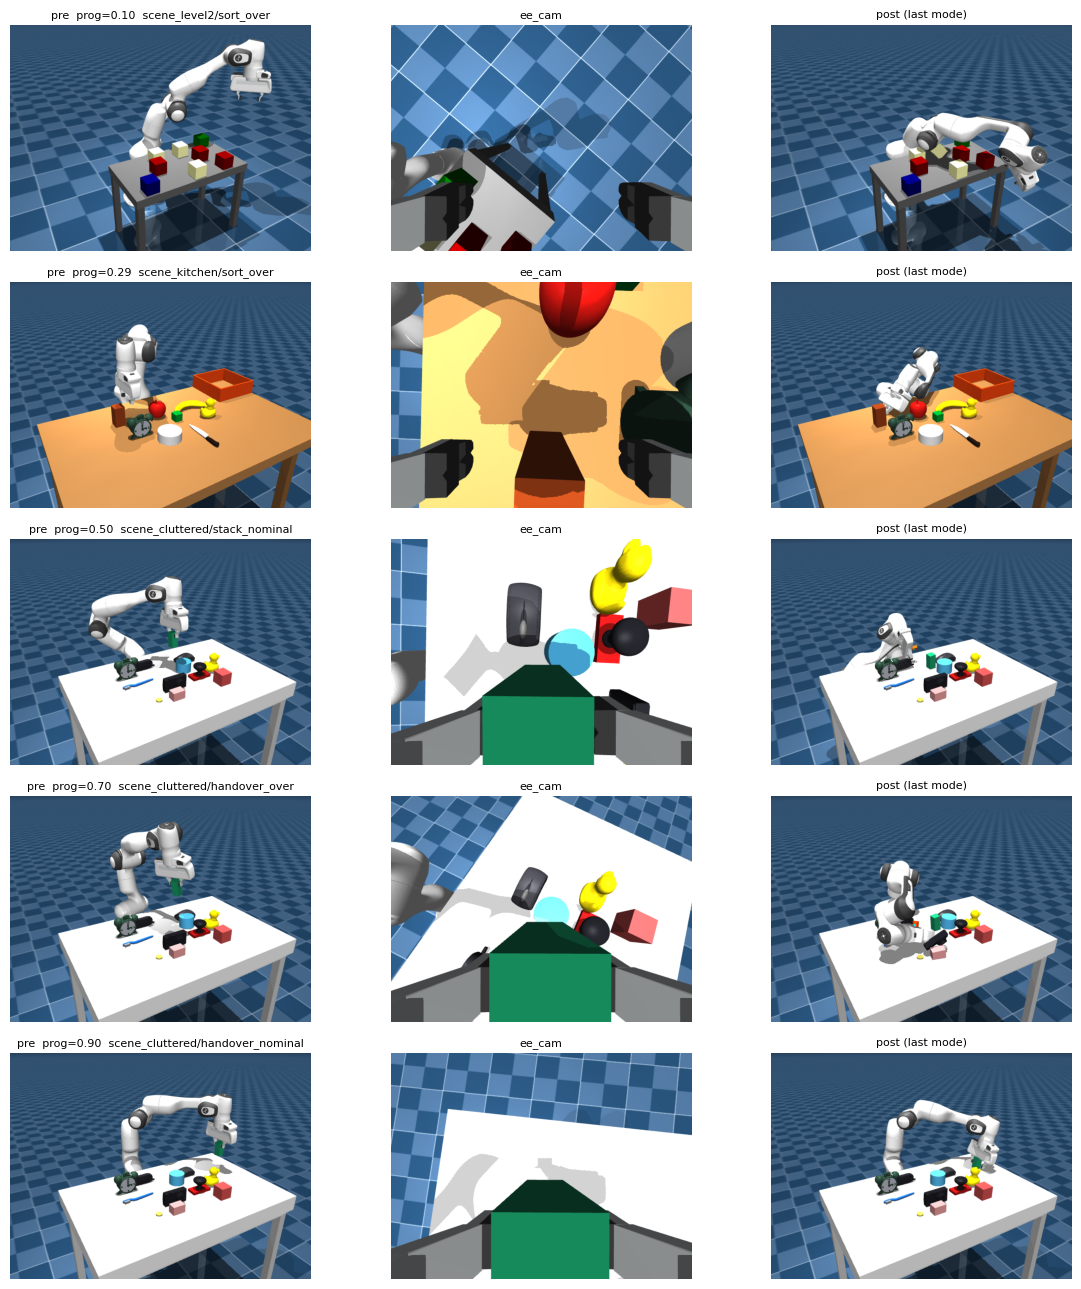

In [12]:
fig, axes = plt.subplots(len(loaded), 3, figsize=(12, 2.6 * len(loaded)))
if len(loaded) == 1: axes = axes[None, :]
for i, (prog, path, scene, task, r, d) in enumerate(loaded):
    axes[i, 0].imshow(d['pre_rgb'])
    axes[i, 0].set_title(f'pre  prog={prog:.2f}  {scene}/{task}', fontsize=8)
    axes[i, 1].imshow(d['ee_cam_rgb'])
    axes[i, 1].set_title('ee_cam', fontsize=8)
    axes[i, 2].imshow(d['post_rgb'])
    axes[i, 2].set_title('post (last mode)', fontsize=8)
    for ax in axes[i]: ax.axis('off')
plt.tight_layout(); plt.show()

### 9b. Depth maps (front and wrist, clipped 0.05–2.0 m)

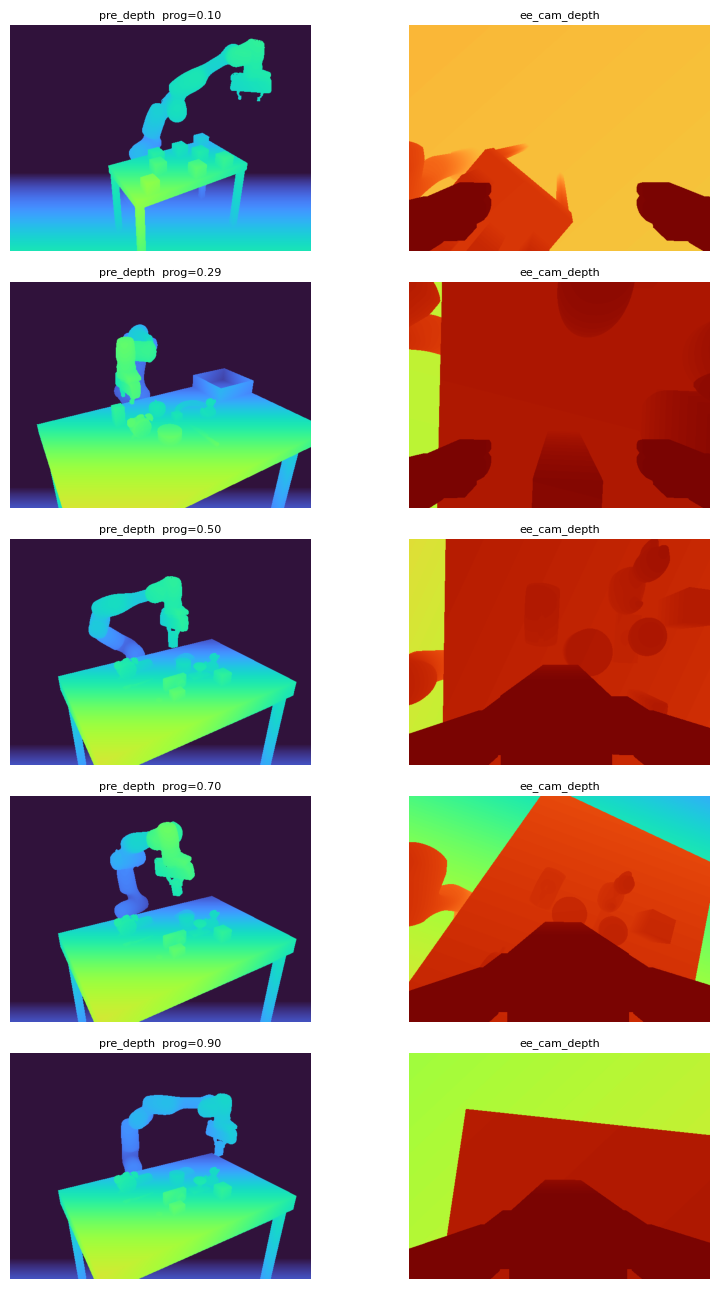

In [13]:
near, far = 0.05, 2.0
fig, axes = plt.subplots(len(loaded), 2, figsize=(9, 2.6 * len(loaded)))
if len(loaded) == 1: axes = axes[None, :]
for i, (prog, path, scene, task, r, d) in enumerate(loaded):
    pd_img = np.clip(d['pre_depth'], near, far)
    ed_img = np.clip(d['ee_cam_depth'], near, far)
    axes[i, 0].imshow(pd_img, cmap='turbo_r', vmin=near, vmax=far)
    axes[i, 0].set_title(f'pre_depth  prog={prog:.2f}', fontsize=8)
    axes[i, 1].imshow(ed_img, cmap='turbo_r', vmin=near, vmax=far)
    axes[i, 1].set_title('ee_cam_depth', fontsize=8)
    for ax in axes[i]: ax.axis('off')
plt.tight_layout(); plt.show()

### 9c. Contact distribution (top-down X–Y, colored by failure mode)

Marker size scales with contact-force magnitude. ALL_JOINTS scatters contacts widely (whole-arm collapse); GRIPPER_OPEN concentrates them near the dropped object.

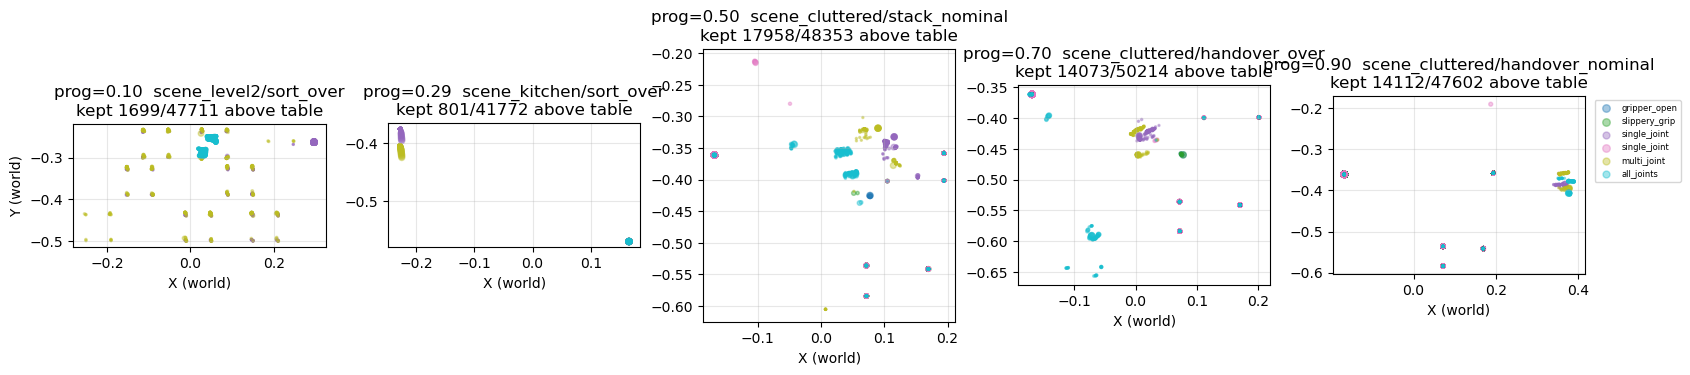

In [14]:
fig, axes = plt.subplots(1, len(loaded), figsize=(3.4 * len(loaded), 3.6))
if len(loaded) == 1: axes = [axes]
for i, (prog, path, scene, task, r, d) in enumerate(loaded):
    ax = axes[i]
    pos = d['contact_positions']; forces = d['contact_forces']; fids = d['contact_failure_id']
    modes = list(d['failure_modes'])
    above = above_table_mask(pos, scene, CONTACT_Z_MARGIN)
    colors = cm.tab10(np.linspace(0, 1, len(modes)))
    for mid, (mode, c) in enumerate(zip(modes, colors)):
        mask = (fids == mid) & above
        if not mask.any(): continue
        p = pos[mask]
        mag = np.linalg.norm(forces[mask, :3], axis=1)
        if len(p) > 400:
            sel = np.random.default_rng(0).choice(len(p), 400, replace=False)
            p, mag = p[sel], mag[sel]
        sizes = 2 + 18 * (mag / (mag.max() + 1e-6))
        ax.scatter(p[:, 0], p[:, 1], s=sizes, c=[c], alpha=0.4, label=mode)
    ax.set(title=f'prog={prog:.2f}  {scene}/{task}\n'
                 f'kept {int(above.sum())}/{len(pos)} above table',
           xlabel='X (world)', ylabel='Y (world)' if i == 0 else '')
    ax.set_aspect('equal'); ax.grid(alpha=0.3)
    if i == len(loaded) - 1:
        ax.legend(fontsize=6, markerscale=1.5, bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout(); plt.show()


### 9d. Ground-truth contacts overlaid on `pre_rgb`

For each of the 5 samples, project the world-frame `contact_positions` into the front-cam pinhole using `ContactProjector`, draw them on top of `pre_rgb`, color by failure mode, scale by `|force|`. This is the closest visual to the supervised target an image-conditioned contact model would predict: given the front-cam pre-failure observation, where in the image are the post-failure contacts?

Caveat — the *pre*-failure image and *post*-failure contacts are from different time instants, so contacts can fall on objects that have moved. The overlay is a faithful visual of the labels we ship in the npz, not a registration claim.

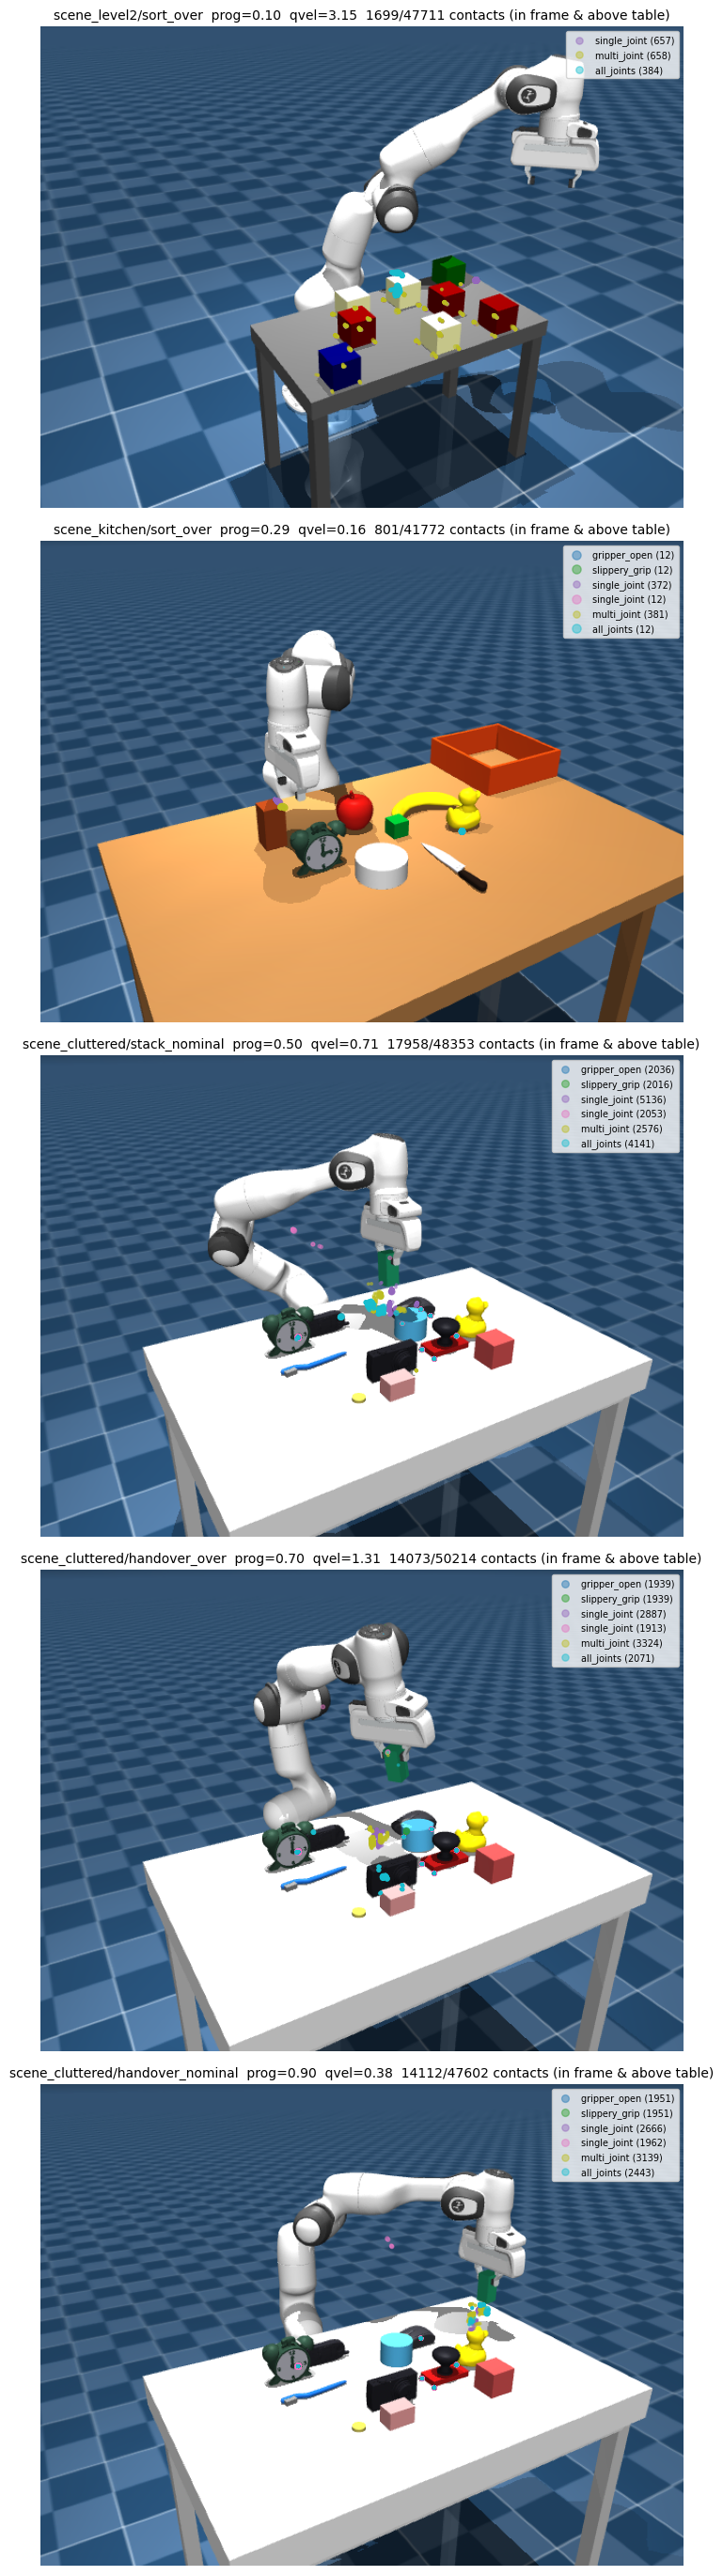

In [15]:
import mujoco
from planner.experiments.data_capture import ContactProjector

# Cache one model + projector per scene so we don't reload for each sample.
_proj_cache = {}
def _projector_for(scene):
    if scene not in _proj_cache:
        m = mujoco.MjModel.from_xml_path(f'scenes/{scene}/scene.xml')
        _proj_cache[scene] = ContactProjector(m, width=640, height=480, camera_name='front_cam')
    return _proj_cache[scene]

fig, axes = plt.subplots(len(loaded), 1, figsize=(8, 5.5 * len(loaded)))
if len(loaded) == 1: axes = [axes]
H, W = 480, 640
for i, (prog, path, scene, task, r, d) in enumerate(loaded):
    ax = axes[i]
    proj = _projector_for(scene)
    pos    = d['contact_positions']
    forces = d['contact_forces']
    fids   = d['contact_failure_id']
    modes  = list(d['failure_modes'])
    pixels, depths = proj.project(pos)
    visible = (depths > 0) & (pixels[:, 0] >= 0) & (pixels[:, 0] < W) \
                            & (pixels[:, 1] >= 0) & (pixels[:, 1] < H)
    above = above_table_mask(pos, scene, CONTACT_Z_MARGIN)
    ax.imshow(d['pre_rgb'])
    colors = cm.tab10(np.linspace(0, 1, len(modes)))
    for mid, (mode, c) in enumerate(zip(modes, colors)):
        mask = (fids == mid) & visible & above
        if not mask.any(): continue
        p = pixels[mask]
        mag = np.linalg.norm(forces[mask, :3], axis=1)
        if len(p) > 600:
            sel = np.random.default_rng(0).choice(len(p), 600, replace=False)
            p, mag = p[sel], mag[sel]
        sizes = 3 + 18 * (mag / (mag.max() + 1e-6))
        ax.scatter(p[:, 0], p[:, 1], s=sizes, c=[c], alpha=0.45,
                   label=f'{mode} ({int(((fids == mid) & above).sum())})')
    n_kept = int((visible & above).sum())
    ax.set_title(f'{scene}/{task}  prog={prog:.2f}  '
                 f'qvel={r["pre_qvel_norm"]:.2f}  '
                 f'{n_kept}/{len(pos)} contacts (in frame & above table)', fontsize=10)
    ax.legend(fontsize=7, markerscale=1.5, loc='upper right')
    ax.set_xlim(0, W); ax.set_ylim(H, 0); ax.axis('off')
plt.tight_layout(); plt.show()


## 10. Prior-weighted contact distribution + smoothing

The failure-mode prior `failure_probs` (`[0.35, 0.25, 0.15, 0.10, 0.10, 0.05]` for
gripper_open / slippery_grip / single_joint(j4) / single_joint(j6) / multi_joint /
all_joints) is stored per npz but **not** applied during data generation — every
mode contributes contacts equally to the dataset. To visualize the *expected*
contact field that a planner should minimise, each contact is reweighted by
`failure_probs[contact_failure_id]` at viz time. No regeneration needed.

For each scene we pool every contact above the table and show three panels:

1. **Weighted scatter** — raw points, alpha proportional to per-contact weight.
   Honest but noisy; rare modes (`all_joints`, `multi_joint`) almost vanish.
2. **Weighted 2D histogram** — bin counts × weights on a 1 cm grid. Reveals
   structure but is blocky and sensitive to bin alignment.
3. **Gaussian-blurred heatmap** — same histogram with a small Gaussian filter
   (σ ≈ 2 cm). Recommended view for planner training targets: stable across
   bin choice, smooth gradient for regression losses.

**Why smooth at all?** Contacts are point samples of an underlying continuous
expected-damage field. A single trajectory contributes a few hundred contacts;
the planner needs a dense, differentiable target. Histogram + Gaussian blur is
the cheapest principled estimator (formally a kernel density with a separable
Gaussian kernel) and lets you tune bandwidth (`SIGMA_CM`) independently of bin
size. KDE is the alternative — included as a one-line swap in the code below.


In [16]:
import zipfile

# Pool contacts per scene with prior weights and the above-table filter from §9.
per_scene = {}
for r in manifests:
    if not r['had_any_collision']:
        continue
    scene = r['scene']
    if scene not in SCENE_TABLE_Z:
        continue
    path = os.path.join(DATASET_ROOT, scene, r['_task'], r['npz_file'])
    try:
        d = np.load(path, allow_pickle=True)
    except (zipfile.BadZipFile, OSError, KeyError, EOFError):
        continue
    pos = d['contact_positions']
    if len(pos) == 0:
        continue
    fids = d['contact_failure_id']
    fprobs = d['failure_probs']
    above = above_table_mask(pos, scene, CONTACT_Z_MARGIN)
    if not above.any():
        continue
    p = pos[above]
    w = fprobs[fids[above]].astype(np.float32)
    fmag = np.linalg.norm(d['contact_forces'][above, :3], axis=1).astype(np.float32)
    bucket = per_scene.setdefault(scene, {'pos': [], 'w': [], 'fmag': []})
    bucket['pos'].append(p); bucket['w'].append(w); bucket['fmag'].append(fmag)

for s, b in per_scene.items():
    b['pos']  = np.concatenate(b['pos'])
    b['w']    = np.concatenate(b['w'])
    b['fmag'] = np.concatenate(b['fmag'])
    print(f'  {s:18s}  N={len(b["pos"]):>7d}  sum_w={b["w"].sum():.1f}  table_z={SCENE_TABLE_Z[s]:.2f}')


  scene_cluttered     N=70834739  sum_w=10965772.0  table_z=0.76
  scene_grocery       N=19124342  sum_w=2201332.8  table_z=0.76
  scene_kitchen       N=14489949  sum_w=1731634.2  table_z=0.76
  scene_level2        N=17287765  sum_w=2051720.6  table_z=0.40
  scene_workshop      N=13446304  sum_w=1569249.9  table_z=0.82


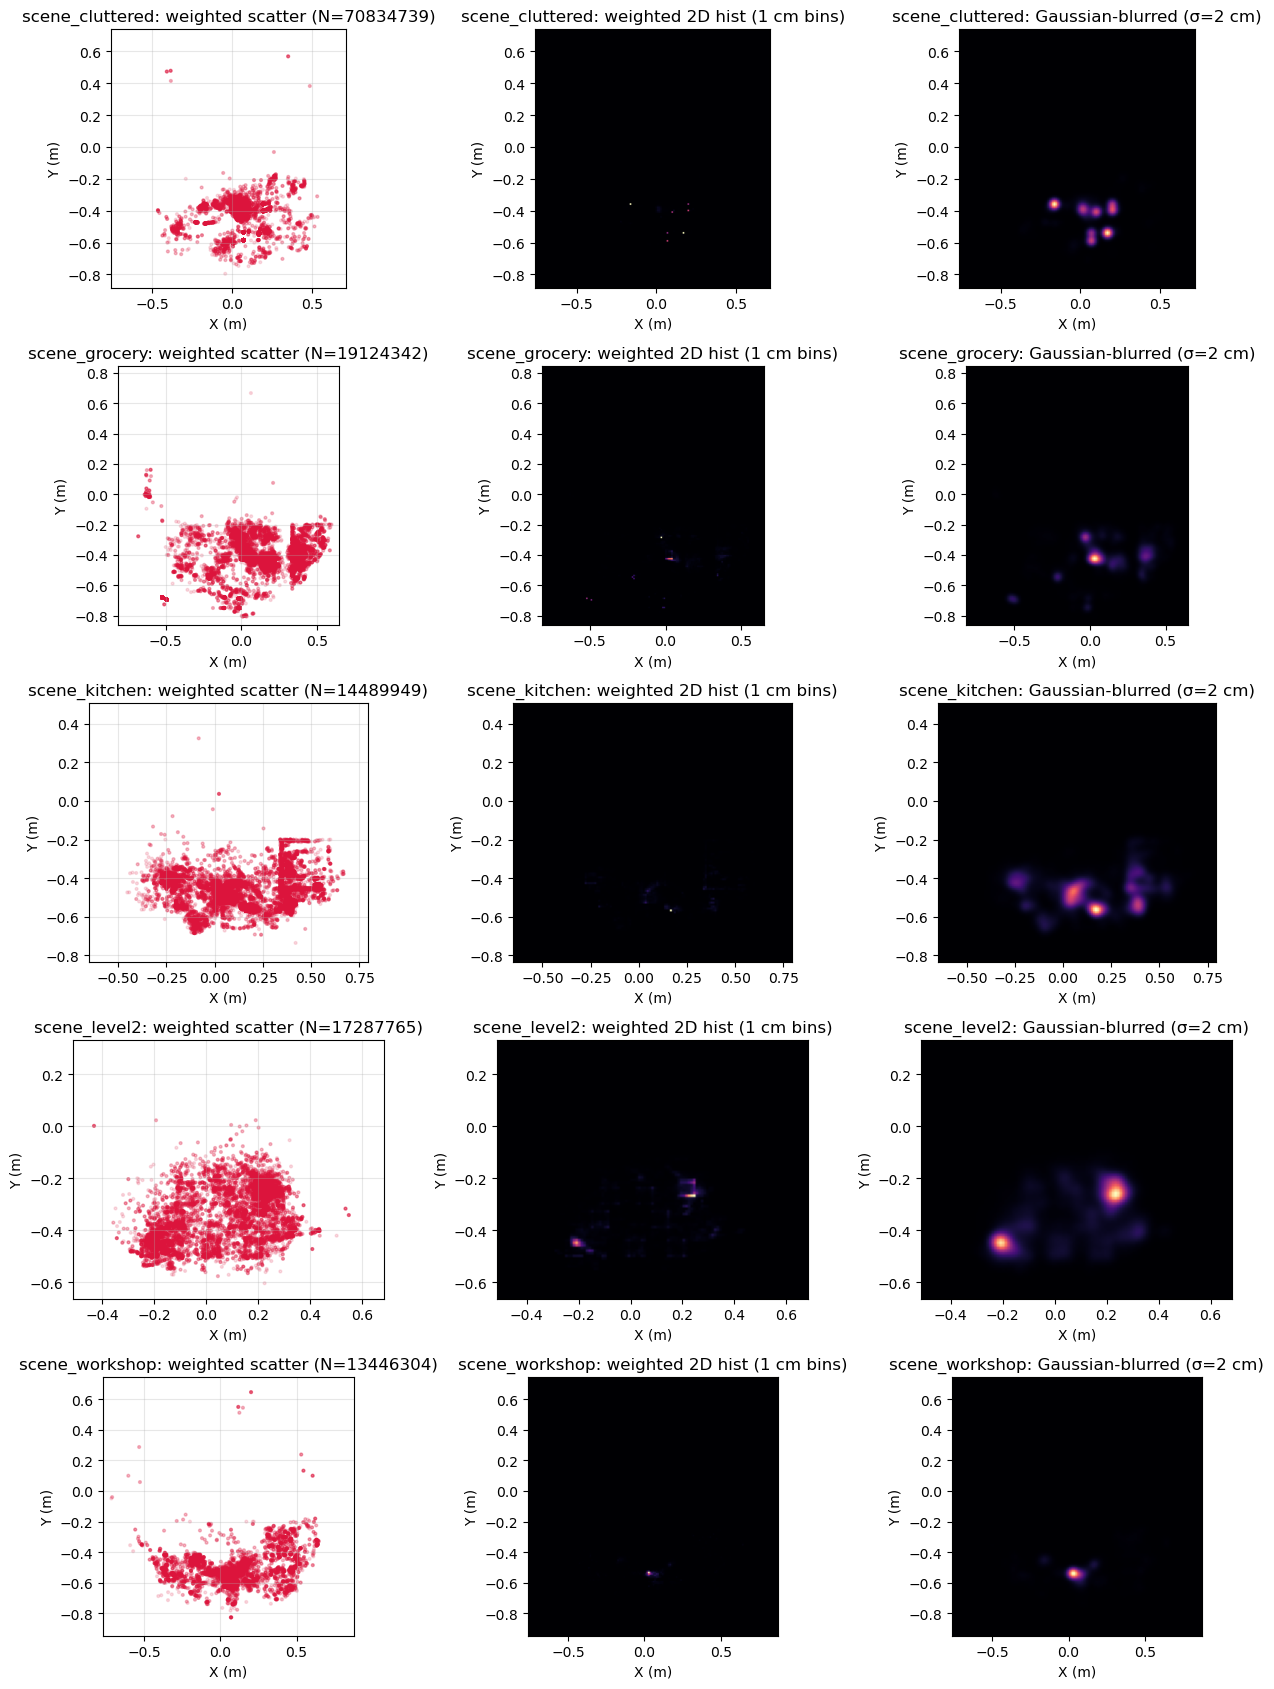

In [17]:
from scipy.ndimage import gaussian_filter

BIN_CM    = 1.0       # histogram bin size (cm)
SIGMA_CM  = 2.0       # Gaussian blur sigma (cm)  — primary smoothing knob
PAD_M     = 0.05      # padding around data extent (m)

scenes_with_data = sorted(per_scene.keys())
fig, axes = plt.subplots(len(scenes_with_data), 3,
                         figsize=(13, 3.4 * len(scenes_with_data)),
                         squeeze=False)

for row, scene in enumerate(scenes_with_data):
    b = per_scene[scene]
    pos, w = b['pos'], b['w']

    x_min, x_max = pos[:, 0].min() - PAD_M, pos[:, 0].max() + PAD_M
    y_min, y_max = pos[:, 1].min() - PAD_M, pos[:, 1].max() + PAD_M

    # Panel A: weighted scatter (subsampled for plotting only)
    axA = axes[row, 0]
    if len(pos) > 8000:
        idx = np.random.default_rng(0).choice(len(pos), 8000, replace=False)
        ps, ws = pos[idx], w[idx]
    else:
        ps, ws = pos, w
    axA.scatter(ps[:, 0], ps[:, 1], s=4, c='crimson',
                alpha=np.clip(ws / ws.max(), 0.05, 0.6))
    axA.set(title=f'{scene}: weighted scatter (N={len(pos)})',
            xlabel='X (m)', ylabel='Y (m)')
    axA.set_aspect('equal'); axA.grid(alpha=0.3)
    axA.set_xlim(x_min, x_max); axA.set_ylim(y_min, y_max)

    # Panel B: weighted 2D histogram
    bin_m = BIN_CM / 100.0
    nx = max(int((x_max - x_min) / bin_m), 8)
    ny = max(int((y_max - y_min) / bin_m), 8)
    H, xe, ye = np.histogram2d(pos[:, 0], pos[:, 1], bins=(nx, ny),
                               range=[[x_min, x_max], [y_min, y_max]],
                               weights=w)
    axB = axes[row, 1]
    axB.imshow(H.T, origin='lower', extent=(x_min, x_max, y_min, y_max),
               cmap='magma', aspect='equal')
    axB.set(title=f'{scene}: weighted 2D hist ({BIN_CM:g} cm bins)',
            xlabel='X (m)', ylabel='Y (m)')

    # Panel C: Gaussian-blurred heatmap (recommended view)
    sigma_bins = SIGMA_CM / BIN_CM
    Hs = gaussian_filter(H, sigma=sigma_bins, mode='constant', cval=0.0)
    axC = axes[row, 2]
    axC.imshow(Hs.T, origin='lower', extent=(x_min, x_max, y_min, y_max),
               cmap='magma', aspect='equal')
    axC.set(title=f'{scene}: Gaussian-blurred (σ={SIGMA_CM:g} cm)',
            xlabel='X (m)', ylabel='Y (m)')

plt.tight_layout(); plt.show()

# Alternative smoothing: KDE (uncomment to swap panel C):
#   from scipy.stats import gaussian_kde
#   kde = gaussian_kde(pos[:, :2].T, weights=w,
#                      bw_method=SIGMA_CM/100/pos[:,:2].std())
#   xx, yy = np.mgrid[x_min:x_max:complex(0, nx), y_min:y_max:complex(0, ny)]
#   Hs = kde(np.vstack([xx.ravel(), yy.ravel()])).reshape(nx, ny)


## 11. Persisted heatmap targets + per-entity integration

`scripts/build_density_targets.py` precomputes a smoothed, prior-weighted
contact heatmap per config and stores it as `targets.npz` in each task
directory, with grid metadata in `<dataset>/<scene>/grid.json`. This section
loads those targets directly (no per-trial physics replay), aggregates per
scene, and **integrates the mean heatmap over each entity’s X-Y footprint**
to recover per-entity interaction scores. Multiplied by hand-set severity
$S(e_i)$ later, this gives the safety cost in the paper’s risk formulation
$\text{Risk} = \sum_i P_\text{interaction}(e_i) \cdot S(e_i)$.

The integrated score is **not** a probability — it’s a relative impact magnitude
suitable for ranking configs. Normalize by `total_weight` (or pass through a
saturating function) at training time if a probabilistic interpretation is
needed.


In [18]:
import json
from pathlib import Path
import mujoco
from planner.risk.spatial import (
    SceneGrid, load_grid, entity_footprints, integrate_per_entity)

# Load per-scene grids and build entity footprints once.
scene_grids = {}
scene_footprints = {}
scene_models = {}
for scene in scenes:
    grid_path = Path(DATASET_ROOT) / scene / 'grid.json'
    if not grid_path.exists():
        print(f'[{scene}] no grid.json - run build_density_targets.py')
        continue
    grid = load_grid(grid_path)
    model = mujoco.MjModel.from_xml_path(f'scenes/{scene}/scene.xml')
    scene_grids[scene] = grid
    scene_footprints[scene] = entity_footprints(model, grid)
    scene_models[scene] = model
    print(f'  {scene:18s}  grid={grid.shape}  entities={len(scene_footprints[scene])}')


  scene_cluttered     grid=(75, 110)  entities=13
  scene_grocery       grid=(66, 130)  entities=10
  scene_kitchen       grid=(86, 130)  entities=10
  scene_level2        grid=(43, 70)  entities=9
  scene_workshop      grid=(93, 133)  entities=8


In [19]:
# Aggregate the persisted heatmaps per scene (mean across all tasks/configs).
scene_mean_heatmap = {}
scene_n = {}
for scene in scene_grids:
    chunks = []
    for tdir in sorted((Path(DATASET_ROOT) / scene).iterdir()):
        tpath = tdir / 'targets.npz'
        if tpath.is_file():
            with np.load(tpath) as t:
                chunks.append(t['target_heatmap'])
    if not chunks:
        continue
    stack = np.concatenate(chunks, axis=0)
    scene_mean_heatmap[scene] = stack.mean(axis=0)
    scene_n[scene] = len(stack)
    print(f'  {scene:18s}  N_configs={len(stack):>5d}  mean_max={scene_mean_heatmap[scene].max():.3f}')


  scene_cluttered     N_configs= 3423  mean_max=38.201
  scene_grocery       N_configs= 3800  mean_max=54.026
  scene_kitchen       N_configs= 2750  mean_max=34.786
  scene_level2        N_configs= 2834  mean_max=5.530
  scene_workshop      N_configs= 3725  mean_max=16.801


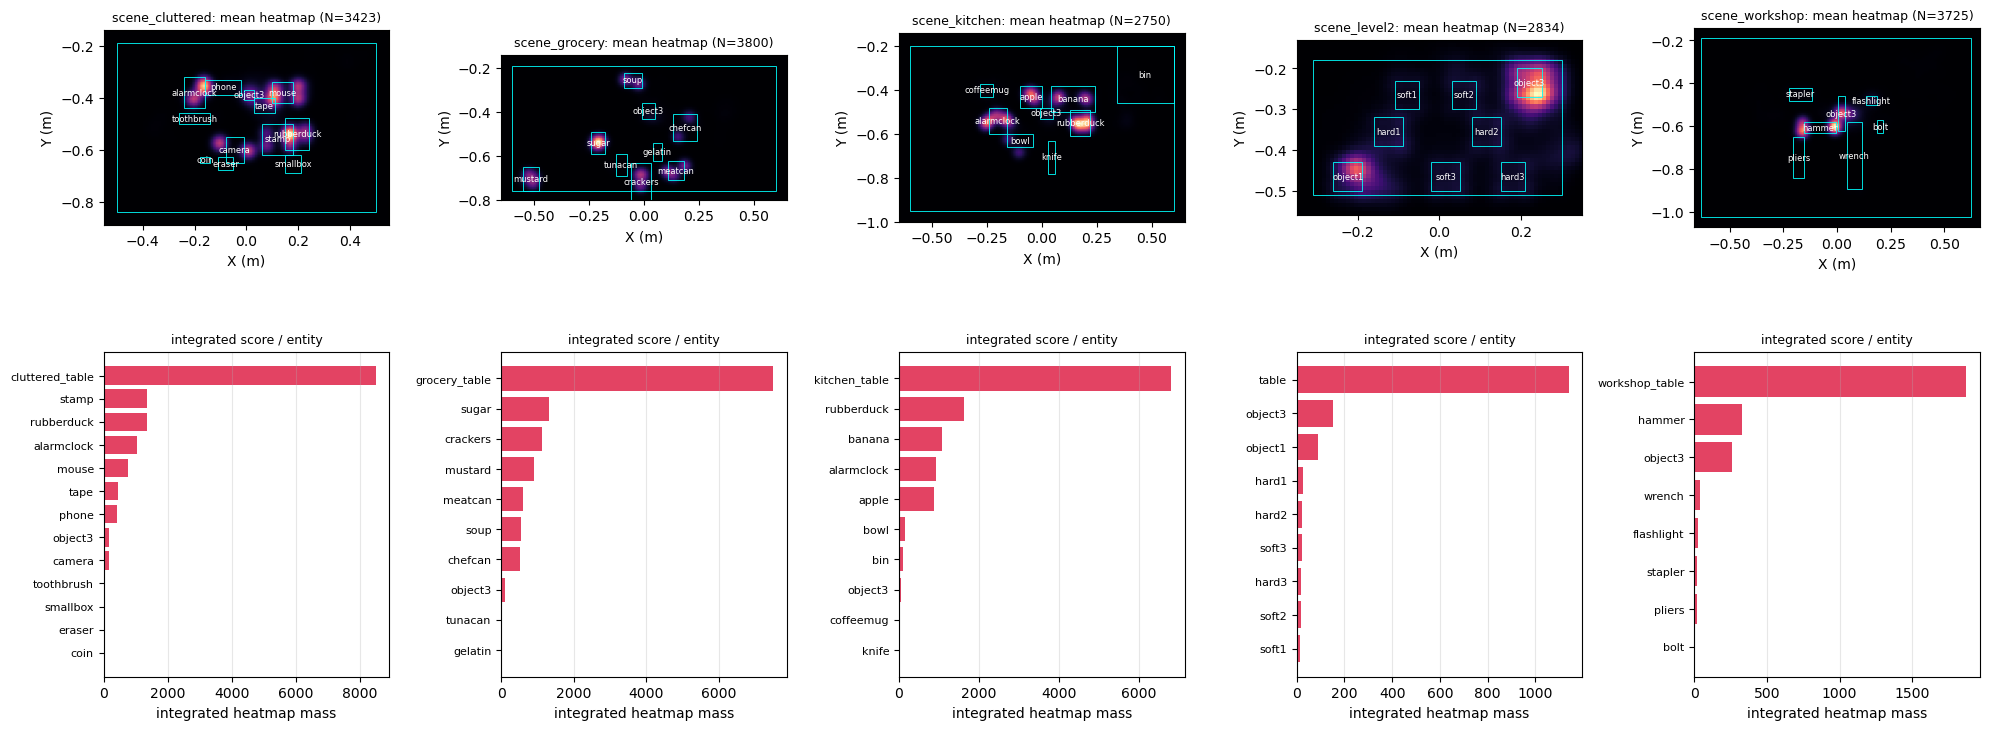

In [20]:
fig, axes = plt.subplots(2, len(scene_mean_heatmap), figsize=(4 * len(scene_mean_heatmap), 8.5),
                          gridspec_kw={'height_ratios': [1.4, 1]})
if len(scene_mean_heatmap) == 1: axes = axes.reshape(2, 1)

for col, (scene, H) in enumerate(scene_mean_heatmap.items()):
    grid = scene_grids[scene]
    fp = scene_footprints[scene]

    # Top row: mean heatmap with entity AABB outlines.
    ax = axes[0, col]
    ax.imshow(H, origin='lower', extent=grid.extent, cmap='magma', aspect='equal')
    for name, mask in fp.items():
        ys, xs = np.where(mask)
        if not len(xs): continue
        x_lo = grid.x_min + xs.min() * grid.bin_cm/100
        x_hi = grid.x_min + (xs.max()+1) * grid.bin_cm/100
        y_lo = grid.y_min + ys.min() * grid.bin_cm/100
        y_hi = grid.y_min + (ys.max()+1) * grid.bin_cm/100
        ax.add_patch(plt.Rectangle((x_lo, y_lo), x_hi-x_lo, y_hi-y_lo,
                                    fill=False, ec='cyan', lw=0.6))
        cx, cy = (x_lo+x_hi)/2, (y_lo+y_hi)/2
        if 'table' not in name:   # skip table label - it covers everything
            ax.annotate(name.replace('obstacle_',''), (cx, cy), color='white',
                        fontsize=6, ha='center', va='center')
    ax.set_title(f'{scene}: mean heatmap (N={scene_n[scene]})', fontsize=9)
    ax.set_xlabel('X (m)'); ax.set_ylabel('Y (m)')

    # Bottom row: per-entity integrated score, sorted descending.
    ax = axes[1, col]
    scores = integrate_per_entity(H, fp)
    items = sorted(scores.items(), key=lambda x: -x[1])
    names = [n.replace('obstacle_', '').replace('simple_', '') for n, _ in items]
    vals  = [v for _, v in items]
    bars = ax.barh(range(len(names)), vals, color='crimson', alpha=0.8)
    ax.set_yticks(range(len(names))); ax.set_yticklabels(names, fontsize=8)
    ax.invert_yaxis(); ax.set_title(f'integrated score / entity', fontsize=9)
    ax.set_xlabel('integrated heatmap mass')
    ax.grid(alpha=0.3, axis='x')

plt.tight_layout(); plt.show()


In [21]:
# Sanity check: integrated score from heatmap vs raw per-entity hit count
# from contact_geom_pairs. They should be highly Spearman-correlated; if not,
# grid resolution or smoothing sigma is too coarse for the entity vocabulary.
from scipy.stats import spearmanr
from planner.experiments.data_capture import _ROBOT_BODY_NAMES

def _entity_hit_count(npz, model, scene, fprobs_weighted=True):
    """Per-entity prior-weighted hit count from raw contact_geom_pairs."""
    pairs = npz['contact_geom_pairs']
    fids  = npz['contact_failure_id']
    fprobs = npz['failure_probs']
    pos = npz['contact_positions']
    above = pos[:, 2] >= (SCENE_TABLE_Z[scene] - 0.01)
    if not above.any(): return {}
    pairs = pairs[above]; fids = fids[above]
    out = {}
    for (g0, g1), m in zip(pairs, fids):
        for gid in (g0, g1):
            bid = model.geom_bodyid[gid]
            bname = mujoco.mj_id2name(model, mujoco.mjtObj.mjOBJ_BODY, bid)
            if not bname or bname in _ROBOT_BODY_NAMES: continue
            w = float(fprobs[m]) if fprobs_weighted else 1.0
            out[bname] = out.get(bname, 0.0) + w
            break
    return out

# Spot-check on a sample of 200 trials per scene
results = {}
for scene in scene_grids:
    grid = scene_grids[scene]; fp = scene_footprints[scene]; model = scene_models[scene]
    rho_per_entity = {n: ([], []) for n in fp}
    rng = np.random.default_rng(0)
    files = []
    for tdir in (Path(DATASET_ROOT) / scene).iterdir():
        files.extend(tdir.glob('exp_*.npz'))
    sample = rng.choice(files, size=min(200, len(files)), replace=False)
    for f in sample:
        with np.load(f) as d:
            from planner.risk.spatial import compute_target
            H, _, _ = compute_target(d, scene, grid)
            integ = integrate_per_entity(H, fp)
            raw   = _entity_hit_count(d, model, scene)
            for name in fp:
                rho_per_entity[name][0].append(integ.get(name, 0.0))
                rho_per_entity[name][1].append(raw.get(name, 0.0))
    flat_int  = np.concatenate([np.array(v[0]) for v in rho_per_entity.values()])
    flat_raw  = np.concatenate([np.array(v[1]) for v in rho_per_entity.values()])
    rho, _ = spearmanr(flat_int, flat_raw)
    results[scene] = rho
    print(f'  {scene:18s}  Spearman(integrated, raw_hits) = {rho:.3f}')


  scene_cluttered     Spearman(integrated, raw_hits) = 0.470
  scene_grocery       Spearman(integrated, raw_hits) = 0.201
  scene_kitchen       Spearman(integrated, raw_hits) = 0.346
  scene_level2        Spearman(integrated, raw_hits) = 0.721
  scene_workshop      Spearman(integrated, raw_hits) = 0.646


## 12. Summary for downstream ML

If everything above looks healthy, the dataset at `DATASET_ROOT` is ready for training. Reminders:

- **Each npz = 6 training examples** (one per failure mode tag in `contact_failure_id`).
- **Trajectory-level split** to avoid leakage: trials sharing `(scene, task_id, traj_id)` should not straddle train/test.
- **Drop ubiquitous geoms** (floor=0, fingertips ~93–96) from the multi-label target — they're contact-by-construction and dominate the loss.
- **PoC OOD recipe**: hold out one scene (recommended `scene_grocery` for its unique shelf/wall geometry); split the other four 80/10/10 at the trajectory level.
- **Failure-mode probabilities** are stored in `failure_probs` per npz — apply at training/eval time as importance weights, no re-generation needed.